# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [1]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("../data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [3]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()
clean = df.copy()
print(clean.shape)
clean.info()
#clean.describe(include="all").T

print(clean.duplicated().sum()) # 720 many duplicates

print("\n2. MSRP most common values:")
print(df["MSRP"].value_counts().head())                    
print("   Rows with MSRP == 2000:", (df["MSRP"] == 2000).sum()) # $2,000 appears 1,036 times

print("\n3. Rows per year:")
print(df["Year"].value_counts().sort_index())
print("   Rows in 2015-2017:", df["Year"].between(2015, 2017).sum())   # expect 5,995

print("\n4. Transmission Type values:")
print(df["Transmission Type"].value_counts(dropna=False))
print("   UNKNOWN rows:", (df["Transmission Type"] == "UNKNOWN").sum())  # expect 19

print("\n5. Engine Cylinders missing:", df["Engine Cylinders"].isna().sum())  # expect 30
print(df[df["Engine Cylinders"].isna()][["Make", "Model", "Engine Fuel Type"]]
      .value_counts())

(11914, 15)
<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Vehicle Size       11914 non-null  str    
 10  Vehicle Style      11914 non-null  str    
 11  highway MPG        11914 non-null  int64  
 12  city mpg           11914 non-null  int64  
 13  Popularity         11914 non-null  int64  
 14  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(7)
memory usage: 1.4 MB
720

2. MSRP mos

**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 |Duplicated Rows |Used .duplicated().sum() | 720| Dropped |No need for duplicates |
| 2 |MSRP placeholder $2000|MSRP.value_counts*() |1,036 |set to NaN for the MSRP |$2000 is set for unknown number |
| 3 |Uneven Year coverage |Year.value_counts() |5,995 |Flag |analysis would be more reflective of newer years |
| 4 | Placeholder in Transmission type |value_counts() |19 |Setm to NaN |a missing value written as a string which can mess up analysis |
| 5 |Missing Engine Cylinders | isna().sum()| 30|Leave alone | those engines dont have a count|

In [4]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names
clean = clean.drop_duplicates().reset_index(drop=True)
clean.loc[clean["msrp"] == 2000, "msrp"] = np.nan
clean["recent_year"] = clean["year"].between(2015, 2017)
clean["transmission_type"] = clean["transmission_type"].replace("UNKNOWN", np.nan)

In [5]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11194, 16)
engine_fuel_type       3
engine_hp             69
engine_cylinders      30
transmission_type     12
number_of_doors        6
msrp                 747
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

44788.66689001627 31870.0


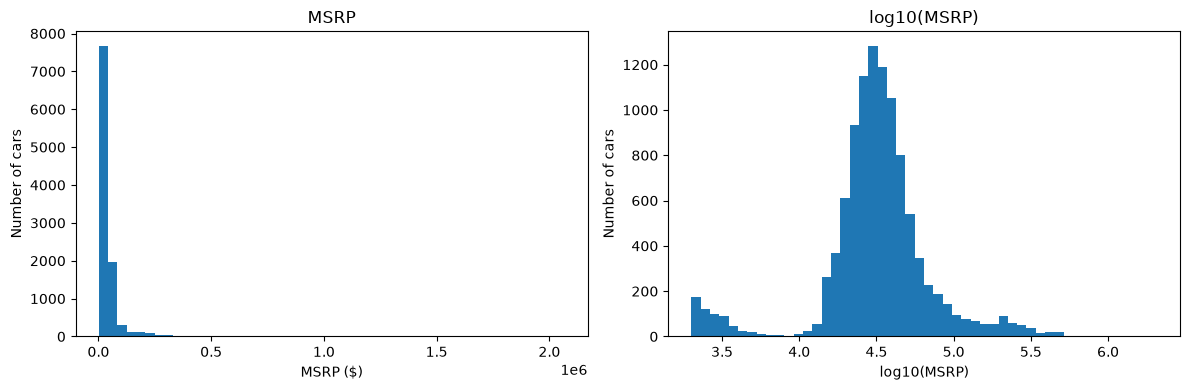

24.447209725279983


In [6]:
prices = clean["msrp"].dropna()
#drop the NaN values as they need to be excluded
# a) mean and median
mean_msrp = prices.mean()
median_msrp = prices.median()
print(mean_msrp, median_msrp)

# b) two histograms side by side (plt.subplots(1, 2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(prices, bins=50)
axes[0].set_title("MSRP")
axes[0].set_xlabel("MSRP ($)")
axes[0].set_ylabel("Number of cars")

axes[1].hist(np.log10(prices), bins=50)
axes[1].set_title("log10(MSRP)")
axes[1].set_xlabel("log10(MSRP)")
axes[1].set_ylabel("Number of cars")

plt.tight_layout()
plt.show()
# c) share of cars above the mean
pct_above_mean = (prices > mean_msrp).mean() * 100
print(pct_above_mean)

**Answer:**
1. The mean will be bigger because the high outliers skew the mean to make it higher than the real average.
2. The first histogram is slightly skewed to the right while the second one is more evenly distributed
3. There is about 24% of the cars that cost above the mean. It is not closer to 50% as you would excpect from an average as the high outliers make the mean a higher value than the average really is.
4. The median would be a better choice to put on the homepage as it is a more realistic number for what the average price of a car is.


### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [11]:
cars17 = clean[clean["year"] == 2017].copy()
# a) mean and std of highway_mpg by vehicle_size, 2017 only
cars17 = cars17[cars17["engine_fuel_type"] != "electric"] #electric are done in a different unit
cars17 = cars17.dropna(subset=["highway_mpg", "vehicle_size"])

size_stats = cars17.groupby("vehicle_size")["highway_mpg"].agg(["count", "mean", "std"])
print(size_stats.round(2))

civic = cars17[(cars17["make"] == "Honda") & (cars17["model"] == "Civic") &
               (cars17["highway_mpg"] == 42)]
s90 = cars17[(cars17["make"] == "Volvo") & (cars17["model"] == "S90")]

print(civic[["make", "model", "vehicle_size", "highway_mpg"]].drop_duplicates())
print(s90[["make", "model", "vehicle_size", "highway_mpg"]].drop_duplicates())

def z_score(row):
    stats = size_stats.loc[row["vehicle_size"]]
    return (row["highway_mpg"] - stats["mean"]) / stats["std"]

civic_row = civic.iloc[0]
s90_row = s90.iloc[0]

z_civic = z_score(civic_row)
z_s90 = z_score(s90_row)

print(f"\nHonda Civic = {z_civic:.2f}")
print(f"Volvo S90 = {z_s90:.2f}")
# b) z = (value - class mean) / class std

              count   mean    std
vehicle_size                     
Compact         509  30.88   6.05
Large           468  22.99   3.49
Midsize         639  29.92  13.95
       make  model vehicle_size  highway_mpg
2434  Honda  Civic      Midsize           42
       make model vehicle_size  highway_mpg
8375  Volvo   S90        Large           34
8376  Volvo   S90        Large           31

Honda Civic = 0.87
Volvo S90 = 3.15


**Answer:**
1. Compact mean = 30.88 sd= 6.05. large mean = 22.99 sd=2.49. midsize 29.92 sd 13.95
2.Honda = 0.87 Volvo = 3.15
3. From the standard deviations that we got, it seems that the volvo is more fuel-efficient and also got an ordinary score. the Volvo got a 3 which is not ordinary at all


---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

Number of cars: 1624
Median MSRP: 36737.5
95% interval: 35940.0 to 37682.5625


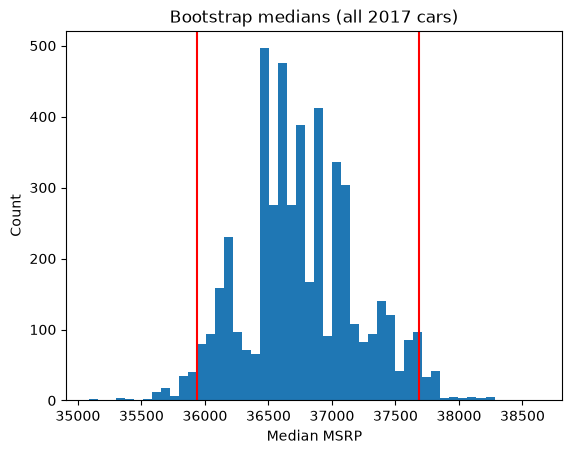

In [13]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    # hint: rng.choice(values, size=len(values), replace=True)
    pass

# a, b)
cars_2017 = clean[clean["year"] == 2017]
prices = cars_2017["msrp"].dropna().values

print("Number of cars:", len(prices))
print("Median MSRP:", np.median(prices))

def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    medians = []
    for i in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        medians.append(np.median(sample))
    return np.array(medians)

medians = bootstrap_median(prices)

low = np.percentile(medians, 2.5)
high = np.percentile(medians, 97.5)
print("95% interval:", low, "to", high)

plt.hist(medians, bins=50)
plt.axvline(low, color="red")
plt.axvline(high, color="red")
plt.title("Bootstrap medians (all 2017 cars)")
plt.xlabel("Median MSRP")
plt.ylabel("Count")
plt.show()
# c)

**Answer:**
The single-make interval should be wider, because with fewer cars each one has a bigger effect on the median.

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

Number of cars: 509
Mean: 30.88015717092338
Median: 30.0
Std: 6.045381133238401


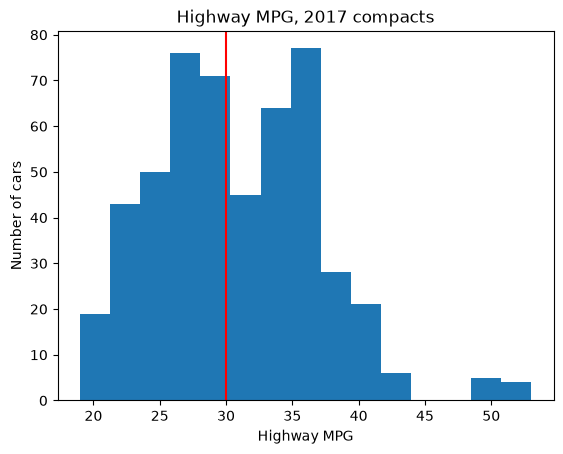

t = 3.2846979278764468
p = 0.0005456796119875344
Reject H0
make        model   
Toyota      Tacoma      27
Chevrolet   Corvette    24
Nissan      Frontier    22
            370Z        17
Porsche     911         14
Honda       Civic       13
Audi        A3          12
Volkswagen  Golf GTI    10
Nissan      Juke        10
Chevrolet   Sonic       10
dtype: int64
Number of rows: 509
Number of distinct models: 85
Models: 85
Mean: 31.68526472886335
t = 2.5773313510555917
p = 0.005851341042610617


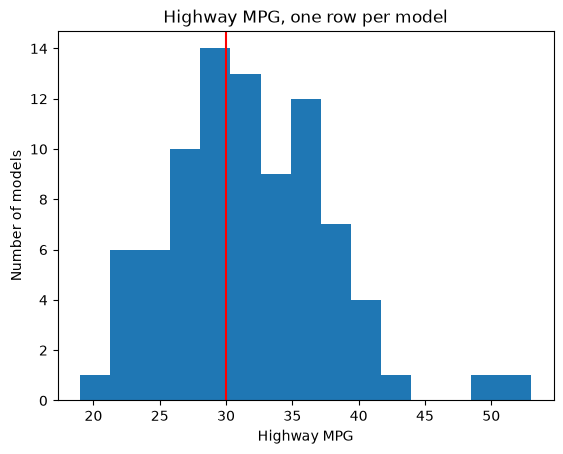

In [14]:
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
compacts = clean[(clean["year"] == 2017) & (clean["vehicle_size"] == "Compact")]
compacts = compacts[compacts["engine_fuel_type"] != "electric"]   # EVs use MPGe, a different unit
compacts = compacts.dropna(subset=["highway_mpg"])

mpg = compacts["highway_mpg"]
print("Number of cars:", len(mpg))
print("Mean:", mpg.mean())
print("Median:", mpg.median())
print("Std:", mpg.std())

plt.hist(mpg, bins=15)
plt.axvline(30, color="red")
plt.title("Highway MPG, 2017 compacts")
plt.xlabel("Highway MPG")
plt.ylabel("Number of cars")
plt.show()


# c) one-sample t-test vs 30
t_stat, p_value = stats.ttest_1samp(mpg, 30, alternative="greater")
print("t =", t_stat)
print("p =", p_value)
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")
# d) rows per make+model, then one row per model and retest
rows_per_model = compacts.groupby(["make", "model"]).size().sort_values(ascending=False)
print(rows_per_model.head(10))
print("Number of rows:", len(compacts))
print("Number of distinct models:", len(rows_per_model))

# average to one row per model
by_model = compacts.groupby(["make", "model"])["highway_mpg"].mean()
print("Models:", len(by_model))
print("Mean:", by_model.mean())

t2, p2 = stats.ttest_1samp(by_model, 30, alternative="greater")
print("t =", t2)
print("p =", p2)

plt.hist(by_model, bins=15)
plt.axvline(30, color="red")
plt.title("Highway MPG, one row per model")
plt.xlabel("Highway MPG")
plt.ylabel("Number of models")
plt.show()

**Answer:**
1. H₀ = 30 Hₐ > 30 This would be one sided because the marketing's claim is over 30 . The only evidence that would support the claim would be if it was over 30.
2. There are 509 cars included in the sample and the distribution looks fairly normal with a small skew to the right. I think a t test is reasonable due to the large number of sample size
3. The sample mean isn't far enough above 30 to rule out chance, so we can't support the claim.
4. Many rows share a make and model so those rows aren't independent, because a civic with three trims is mostly one car counted three times. That makes the first test's sample size smaller than it looks.

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [ ]:
1.The median of an automatic is  33620.0 while the median of a manual is 21875.0.
2. From the histogram, we can see that there are a lot more manual automatic cars in the most recent years, and before until about the 2000, there were more manuals than automatics
3.
4.

transmission_type
AUTOMATIC    33620.0
MANUAL       21875.0
Name: msrp, dtype: float64
transmission_type
AUTOMATIC    7635
MANUAL       2184
Name: msrp, dtype: int64
                    count         mean       std     min     25%     50%  \
transmission_type                                                          
AUTOMATIC          7635.0  2012.533857  5.211005  1990.0  2010.0  2015.0   
MANUAL             2184.0  2009.136905  7.095968  1990.0  2003.0  2011.0   

                      75%     max  
transmission_type                  
AUTOMATIC          2016.0  2017.0  
MANUAL             2015.0  2017.0  


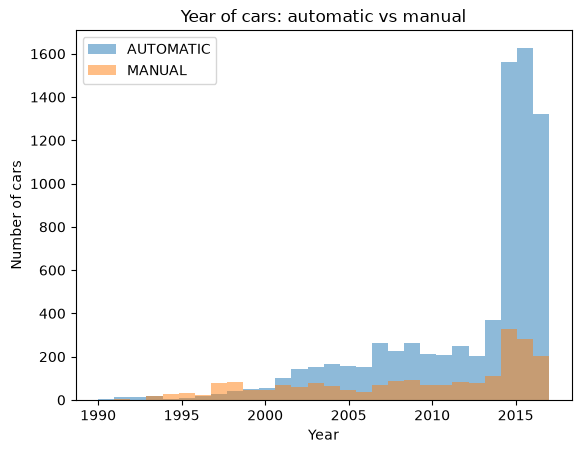

Median MSRP, 2015-2017 only
transmission_type
AUTOMATIC    37065.0
MANUAL       26905.0
Name: msrp, dtype: float64

Median MSRP by vehicle size
                                count   median
vehicle_size transmission_type                
Compact      AUTOMATIC           1119  25995.0
             MANUAL               589  25860.0
Large        AUTOMATIC           1473  44400.0
             MANUAL                26  38395.0
Midsize      AUTOMATIC           1919  37980.0
             MANUAL               198  26920.0

Compacts, 2015-2017
Automatic: n = 1119 , median = 25995.0
Manual:    n = 589 , median = 25860.0
U = 317261.0
p = 0.20483161191397048


In [18]:
# a) compare median MSRP by transmission type
cars = clean[clean["transmission_type"].isin(["AUTOMATIC", "MANUAL"])]
cars = cars.dropna(subset=["msrp"])

print(cars.groupby("transmission_type")["msrp"].median())
print(cars.groupby("transmission_type")["msrp"].count())

# b) compare year by transmission type


print(cars.groupby("transmission_type")["year"].describe())
cars.groupby("transmission_type")["year"].plot(kind="hist", bins=28, alpha=0.5, legend=True)
plt.title("Year of cars: automatic vs manual")
plt.xlabel("Year")
plt.ylabel("Number of cars")
plt.show()

# c) compare 2015-2017 medians overall and within each vehicle_size
# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)
recent = cars[cars["year"].between(2015, 2017)] 

print("Median MSRP, 2015-2017 only")
print(recent.groupby("transmission_type")["msrp"].median())

print("\nMedian MSRP by vehicle size")
print(recent.groupby(["vehicle_size", "transmission_type"])["msrp"].agg(["count", "median"]))


compacts = recent[recent["vehicle_size"] == "Compact"]
auto = compacts[compacts["transmission_type"] == "AUTOMATIC"]["msrp"]
manual = compacts[compacts["transmission_type"] == "MANUAL"]["msrp"]

print("\nCompacts, 2015-2017")
print("Automatic: n =", len(auto), ", median =", auto.median())
print("Manual:    n =", len(manual), ", median =", manual.median())

u, p = stats.mannwhitneyu(auto, manual)
print("U =", u)
print("p =", p)

**Answer:**
1.The median of an automatic is  33620.0 while the median of a manual is 21875.0.

2.From the histogram, we can see that there are a lot more manual automatic cars in the most recent years, and before until about the 2000, there were more manuals than automatics

3.Manuals look cheaper mostly because they skew older as once we compare 2015–2017 cars of the same size, the gap is smaller.

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [17]:
rng = np.random.default_rng(42)
trusted = clean[clean["engine_fuel_type"] != "electric"]
trusted = trusted[trusted["highway_mpg"] < 200]
trusted = trusted.dropna(subset=["highway_mpg", "number_of_doors"])

four = trusted[trusted["number_of_doors"] == 4]["highway_mpg"]
two = trusted[trusted["number_of_doors"] == 2]["highway_mpg"]
# a) Welch t-test, 4-door vs 2-door
print("4-door: n =", len(four), ", mean =", four.mean())
print("2-door: n =", len(two), ", mean =", two.mean())
print("Difference in means:", four.mean() - two.mean())

t, p = stats.ttest_ind(four, two, equal_var=False)
print("t =", t)
print("p =", p)
# b) yearly gas cost = miles * price_per_gallon / mpg
miles = 12000
price_per_gallon = 3.50

cost_four = miles * price_per_gallon / four.mean()
cost_two = miles * price_per_gallon / two.mean()

print("Yearly cost, 4-door: $", round(cost_four, 2))
print("Yearly cost, 2-door: $", round(cost_two, 2))
print("4-door driver saves: $", round(cost_two - cost_four, 2), "per year")

# c) simulation
n_sims, hits = 1000, 0
for _ in range(n_sims):  
    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    s4 = rng.choice(four, 30, replace=False)
    s2 = rng.choice(two, 30, replace=False)
    t_s, p_s = stats.ttest_ind(s4, s2, equal_var=False)
    if p_s < 0.05:
        hits += 1

print("Fraction significant with n = 30 per group:", hits / n_sims)
n_sims, hits = 1000, 0
for _ in range(n_sims):
    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    pass

4-door: n = 7897 , mean = 26.80473597568697
2-door: n = 2873 , mean = 25.256526279150712
Difference in means: 1.548209696536258
t = 11.93000368852394
p = 2.1056456058924235e-32
Yearly cost, 4-door: $ 1566.89
Yearly cost, 2-door: $ 1662.94
4-door driver saves: $ 96.05 per year
Fraction significant with n = 30 per group: 0.152


**Answer:**
1. The mean for a 4-door is 26.8 (n=7,897) while the 2 door is 25.26 (n=2,873). The difference is about 1.55 MPG. The p value is extremely small which means it is statistically significant and would support the claim.
2. The yearly cost for the 4 door would be 1566.89 while the cost for a 2 door would be 1662.94. This means that the 4 door car saves an average of $96 per year.
3. About 15% of the sample tests came out significant 
4. I would not run an ad based off this data saying "4-door cars are significantly more fuel-efficient" because that makes it seem like they would save massive amounts of money when in reality it is about $100 a year.

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:**

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [ ]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [ ]:
# S2